In [7]:
#!kaggle competitions download -c dogs-vs-cats


  0%|          | 0.00/812M [00:00<?, ?B/s]
  0%|          | 1.00M/812M [00:01<18:08, 781kB/s]
  0%|          | 2.00M/812M [00:01<09:02, 1.57MB/s]
  0%|          | 3.00M/812M [00:01<05:45, 2.46MB/s]
  0%|          | 4.00M/812M [00:01<04:14, 3.33MB/s]
  1%|          | 5.00M/812M [00:01<03:22, 4.19MB/s]
  1%|          | 6.00M/812M [00:02<02:54, 4.86MB/s]
  1%|          | 7.00M/812M [00:02<02:39, 5.31MB/s]
  1%|          | 8.00M/812M [00:02<02:27, 5.72MB/s]
  1%|1         | 9.00M/812M [00:02<02:19, 6.06MB/s]
  1%|1         | 10.0M/812M [00:02<02:13, 6.31MB/s]
  1%|1         | 11.0M/812M [00:02<02:09, 6.50MB/s]
  1%|1         | 12.0M/812M [00:03<02:28, 5.65MB/s]
  2%|1         | 14.0M/812M [00:03<02:07, 6.57MB/s]
  2%|1         | 15.0M/812M [00:03<02:08, 6.49MB/s]
  2%|1         | 16.0M/812M [00:03<02:09, 6.43MB/s]
  2%|2         | 17.0M/812M [00:03<02:11, 6.36MB/s]
  2%|2         | 18.0M/812M [00:04<02:09, 6.45MB/s]
  2%|2         | 19.0M/812M [00:04<01:58, 7.02MB/s]
  2%|2         | 20.0

In [8]:
# import zipfile

# with zipfile.ZipFile("dogs-vs-cats.zip", "r") as zip_ref:
#     zip_ref.extractall("dogs-vs-cats")

# with zipfile.ZipFile("dogs-vs-cats/train.zip", "r") as zip_ref:
#     zip_ref.extractall("dogs-vs-cats")

# print("Done — check the dogs-vs-cats/train folder.")

Done — check the dogs-vs-cats/train folder.


In [7]:
import os, shutil, pathlib

original_dir = pathlib.Path("dogs-vs-cats/train")
new_base_dir = pathlib.Path("cats_vs_dogs_small")

def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir, exist_ok=True)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)

make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

print("Subset created at:", new_base_dir.resolve())

Subset created at: C:\Users\User\Deep Learning Practice\cats_vs_dogs_small


In [8]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)

validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)

test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)


Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [9]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 178, 178, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 89, 89, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 87, 87, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 43, 43, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 41, 41, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 18, 18, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 9, 9, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 7, 7, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │          12,545 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [12]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)


Epoch 1/30


C:\Users\User\miniconda3\envs\dl-env311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 752ms/step - accuracy: 0.5190 - loss: 0.7077 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 796ms/step - accuracy: 0.5270 - loss: 0.6955 - val_accuracy: 0.5010 - val_loss: 0.6909
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 792ms/step - accuracy: 0.5615 - loss: 0.6964 - val_accuracy: 0.5820 - val_loss: 0.6838
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 794ms/step - accuracy: 0.6050 - loss: 0.6593 - val_accuracy: 0.5330 - val_loss: 0.6912
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 723ms/step - accuracy: 0.6425 - loss: 0.6267 - val_accuracy: 0.6810 - val_loss: 0.5902
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 723ms/step - accuracy: 0.6920 - loss: 0.5907 - val_accuracy: 0.6500 - val_loss: 0.6740
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 46s 724ms/step - accuracy: 0.7205 - loss: 0.5517 - val_accuracy: 0.7010 - val_loss: 0.5891
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 86s 792ms/step - accuracy: 0.7420 - loss: 0.5205 - val_accuracy: 0.691

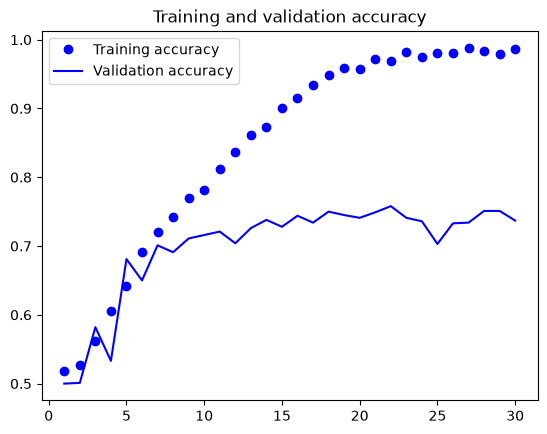

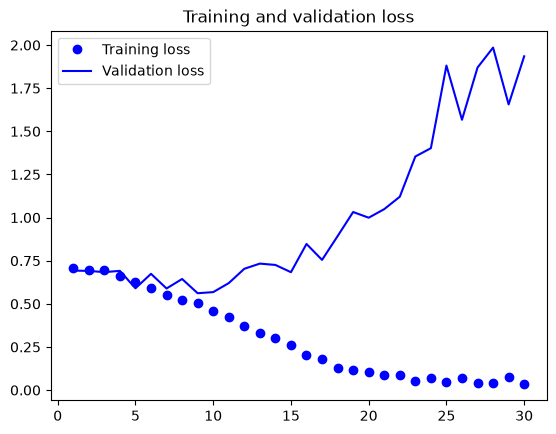

In [13]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.figure()
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()

plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()


In [17]:
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 208ms/step - accuracy: 0.7235 - loss: 0.5805
Test accuracy: 0.724
